# Phase 5: Evaluation - Business and Methodology Review

This notebook evaluates the project using the corrected leakage-safe workflow. Previous random-row-split results are treated as exploratory only.


---
## Section 1: Setup


In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import json
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score
)
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import label_binarize

for path in [os.getcwd(), os.path.join(os.getcwd(), 'notebooks')]:
    if path not in sys.path:
        sys.path.append(path)

from leakage_safe_pipeline import (
    RANDOM_STATE, N_SPLITS, FINAL_FEATURES,
    load_dataset, first_group_holdout, champion_pipeline, evaluate_predictions,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')
%matplotlib inline

FIGURE_DIR = os.path.join('..', 'figure') if os.path.exists(os.path.join('..', 'figure')) else 'figure'
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Phase 5: Leakage-safe evaluation')
print(f'Start time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')


Phase 5: Leakage-safe evaluation
Start time: 2026-07-16 23:06:50


In [3]:
candidate_paths = [
    os.path.join('..', 'data', 'raw', 'fleet_augmented.csv'),
    os.path.join('data', 'raw', 'fleet_augmented.csv'),
]
RAW_DATA_PATH = next(path for path in candidate_paths if os.path.exists(path))

bundle = load_dataset(RAW_DATA_PATH)
split = first_group_holdout(bundle)
X_train = split['X_train']
X_test = split['X_test']
y_train = split['y_train']
y_test = split['y_test']
groups_train = split['groups_train']
groups_test = split['groups_test']

print(f'Rows: train={len(X_train):,}, test={len(X_test):,}')
print(f'Vehicles: train={groups_train.nunique():,}, test={groups_test.nunique():,}')
print(f'Vehicle overlap: {len(set(groups_train) & set(groups_test))}')
assert len(set(groups_train) & set(groups_test)) == 0


Rows: train=16,241, test=4,059
Vehicles: train=401, test=99
Vehicle overlap: 0


---
## Section 2: Champion Model Re-evaluation

LightGBM is re-evaluated using unseen-vehicle holdout data. The conclusion should be based on these metrics, not the previous random split.


In [4]:
champion_name = 'LightGBM'
pipe = champion_pipeline()
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)

metrics = evaluate_predictions(y_test, y_pred)
metrics["Cohen's Kappa"] = cohen_kappa_score(y_test, y_pred)
metrics['MCC'] = matthews_corrcoef(y_test, y_pred)

display(pd.DataFrame([metrics], index=[champion_name]).style.format('{:.4f}'))
print(classification_report(y_test, y_pred, target_names=bundle.class_names, zero_division=0, digits=4))


,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Cohen's Kappa,MCC
LightGBM,0.9919,0.9105,0.8569,0.9105,0.8809,0.9922,0.8889,0.8898


                      precision    recall  f1-score   support

Critical_Overheating     0.7532    0.9062    0.8227        64
   Mechanical_Stress     0.7500    0.9000    0.8182        10
              Normal     0.9979    0.9946    0.9963      3913
    Thermal_Overload     0.9833    0.9516    0.9672        62
         Voltage_Sag     0.8000    0.8000    0.8000        10

            accuracy                         0.9919      4059
           macro avg     0.8569    0.9105    0.8809      4059
        weighted avg     0.9928    0.9919    0.9922      4059



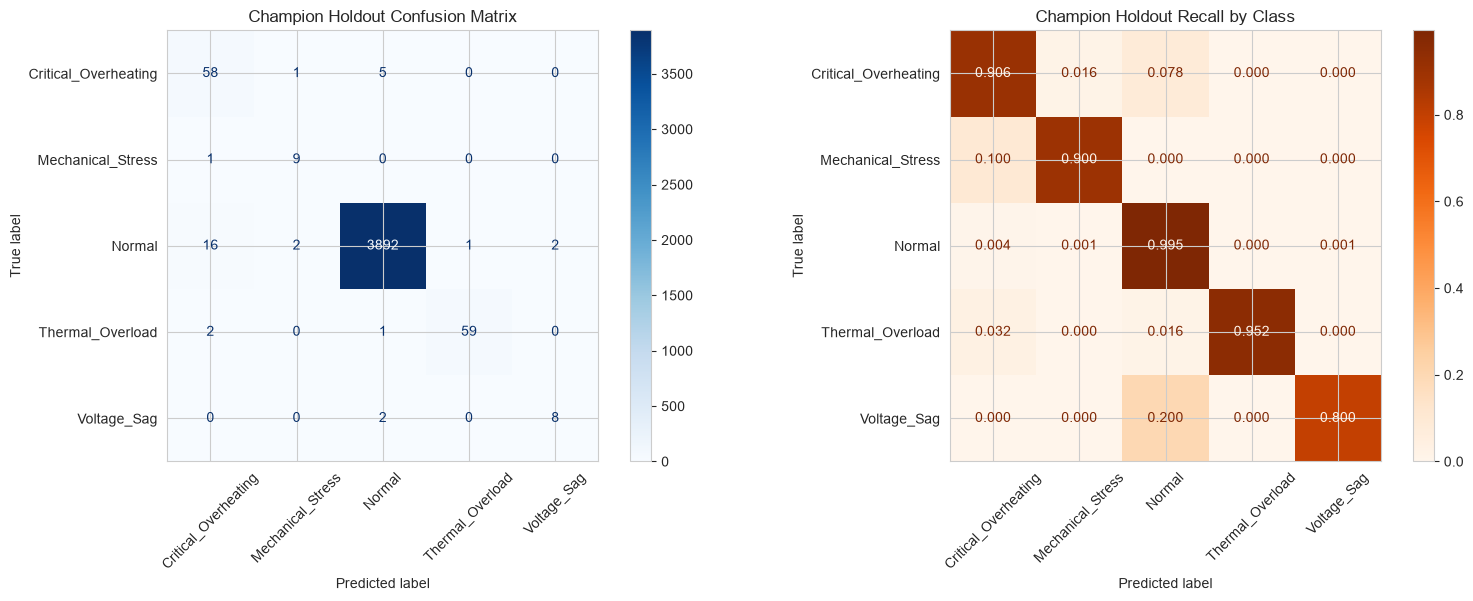

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=bundle.class_names).plot(
    ax=axes[0], cmap='Blues', values_format='d', xticks_rotation=45
)
axes[0].set_title('Champion Holdout Confusion Matrix')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=bundle.class_names).plot(
    ax=axes[1], cmap='Oranges', values_format='.3f', xticks_rotation=45
)
axes[1].set_title('Champion Holdout Recall by Class')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'champion_group_holdout_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Section 3: Failure-Focused Business Assessment

Overall accuracy is reported, but the decision metrics are failure recall and false alarm rate.


In [6]:
normal_label = bundle.label_mapping['Normal']
failure_labels = [idx for idx in sorted(bundle.label_mapping_inv) if idx != normal_label]

rows = []
total_failures = 0
detected_failures = 0
for cls_int in failure_labels:
    cls_name = bundle.label_mapping_inv[cls_int]
    true_mask = (y_test.values == cls_int)
    pred_mask = (y_pred == cls_int)
    support = int(true_mask.sum())
    detected = int((true_mask & pred_mask).sum())
    total_failures += support
    detected_failures += detected
    rows.append({
        'Class': cls_name,
        'Support': support,
        'Detected': detected,
        'Recall': detected / support if support else 0,
        'Precision': precision_score(y_test == cls_int, y_pred == cls_int, zero_division=0),
    })

failure_df = pd.DataFrame(rows)
overall_failure_recall = detected_failures / total_failures if total_failures else 0
normal_mask = (y_test.values == normal_label)
false_alarms = int(((y_pred != normal_label) & normal_mask).sum())
false_alarm_rate = false_alarms / int(normal_mask.sum()) if normal_mask.sum() else 0

display(failure_df.style.format({'Recall': '{:.4f}', 'Precision': '{:.4f}'}))
print(f'Overall failure recall: {overall_failure_recall:.4f} ({detected_failures}/{total_failures})')
print(f'False alarm rate: {false_alarm_rate:.4f} ({false_alarms}/{int(normal_mask.sum())})')


,Class,Support,Detected,Recall,Precision
0,Critical_Overheating,64,58,0.9062,0.7532
1,Mechanical_Stress,10,9,0.9000,0.7500
2,Thermal_Overload,62,59,0.9516,0.9833
3,Voltage_Sag,10,8,0.8000,0.8000


Overall failure recall: 0.9178 (134/146)
False alarm rate: 0.0054 (21/3913)


---
## Section 4: Group-Aware Cross-Validation Stability


In [7]:
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'recall_macro': 'recall_macro',
}

cv_results = cross_validate(
    champion_pipeline(), bundle.X, bundle.y, groups=bundle.groups,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)

cv_summary = pd.DataFrame({
    'metric': list(scoring.keys()),
    'train_mean': [cv_results[f'train_{m}'].mean() for m in scoring],
    'train_std': [cv_results[f'train_{m}'].std() for m in scoring],
    'test_mean': [cv_results[f'test_{m}'].mean() for m in scoring],
    'test_std': [cv_results[f'test_{m}'].std() for m in scoring],
})
display(cv_summary.style.format({
    'train_mean': '{:.4f}', 'train_std': '{:.4f}',
    'test_mean': '{:.4f}', 'test_std': '{:.4f}'
}))


,metric,train_mean,train_std,test_mean,test_std
0,accuracy,1.0000,0.0000,0.9934,0.0014
1,balanced_accuracy,1.0000,0.0000,0.9151,0.0080
2,f1_macro,1.0000,0.0000,0.8831,0.0193
3,f1_weighted,1.0000,0.0000,0.9937,0.0013
4,recall_macro,1.0000,0.0000,0.9151,0.0080


---
## Section 5: Precision-Recall Curves

Precision-recall is more informative than ROC alone for rare failure classes.


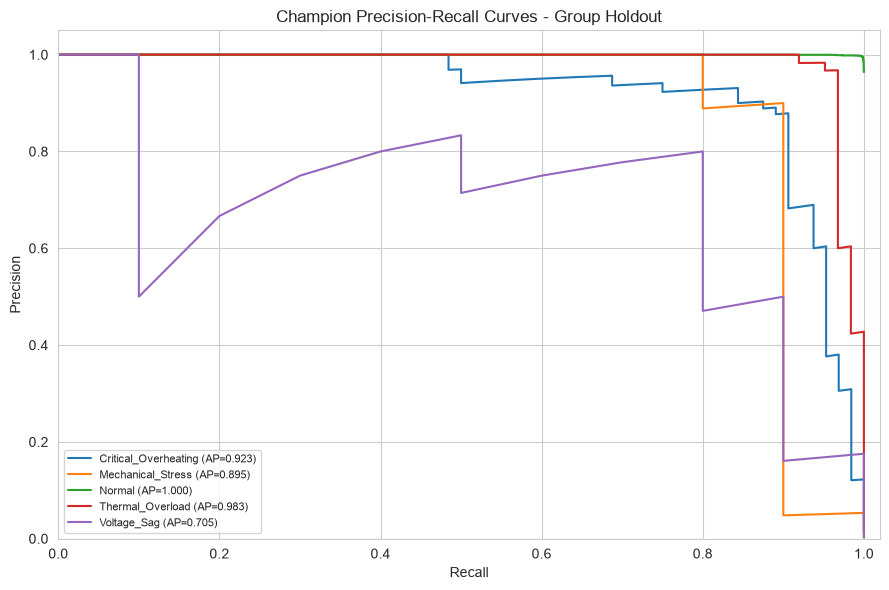

,Class,Average Precision
0,Critical_Overheating,0.9229
1,Mechanical_Stress,0.8953
2,Normal,0.9999
3,Thermal_Overload,0.9833
4,Voltage_Sag,0.7053


In [8]:
y_test_bin = label_binarize(y_test, classes=list(range(len(bundle.class_names))))
fig, ax = plt.subplots(figsize=(9, 6))

ap_rows = []
for i, cls_name in enumerate(bundle.class_names):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    ap_rows.append({'Class': cls_name, 'Average Precision': ap})
    ax.plot(recall, precision, linewidth=1.5, label=f'{cls_name} (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Champion Precision-Recall Curves - Group Holdout')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'champion_group_holdout_precision_recall.png'), dpi=150, bbox_inches='tight')
plt.show()

display(pd.DataFrame(ap_rows).style.format({'Average Precision': '{:.4f}'}))


---
## Section 6: Final Decision


In [9]:
business_thresholds = {
    'minimum_macro_f1': 0.80,
    'minimum_macro_recall': 0.80,
    'minimum_failure_recall': 0.80,
    'maximum_false_alarm_rate': 0.10,
}

decision = {
    'champion_model': champion_name,
    'split_strategy': 'StratifiedGroupKFold holdout by car_id',
    'vehicle_overlap_between_train_test': int(len(set(groups_train) & set(groups_test))),
    'holdout_metrics': {k: float(v) for k, v in metrics.items()},
    'overall_failure_recall': float(overall_failure_recall),
    'false_alarm_rate': float(false_alarm_rate),
    'cv_test_macro_f1_mean': float(cv_results['test_f1_macro'].mean()),
    'cv_test_macro_f1_std': float(cv_results['test_f1_macro'].std()),
    'business_thresholds': business_thresholds,
    'methodology_status': 'defensible if thresholds are met on rerun; otherwise report as prototype needing more data',
    'deployment_caveat': 'Rolling features require recent vehicle history. If production only receives single-row inputs, train/evaluate a no-history variant or maintain per-vehicle rolling state in the backend.',
}

print(json.dumps(decision, indent=2))


{
  "champion_model": "LightGBM",
  "split_strategy": "StratifiedGroupKFold holdout by car_id",
  "vehicle_overlap_between_train_test": 0,
  "holdout_metrics": {
    "Accuracy": 0.991869918699187,
    "Balanced Accuracy": 0.9104992353857695,
    "Macro Precision": 0.8569057609057609,
    "Macro Recall": 0.9104992353857695,
    "Macro F1": 0.8808756411899413,
    "Weighted F1": 0.992184623579741,
    "Cohen's Kappa": 0.8889248229349879,
    "MCC": 0.8898167892479693
  },
  "overall_failure_recall": 0.9178082191780822,
  "false_alarm_rate": 0.005366726296958855,
  "cv_test_macro_f1_mean": 0.8831291782794868,
  "cv_test_macro_f1_std": 0.019273825451536088,
  "business_thresholds": {
    "minimum_macro_f1": 0.8,
    "minimum_macro_recall": 0.8,
    "minimum_failure_recall": 0.8,
    "maximum_false_alarm_rate": 0.1
  },
  "methodology_status": "defensible if thresholds are met on rerun; otherwise report as prototype needing more data",
  "deployment_caveat": "Rolling features require recent